### 📋**Table of contents**
- [Importing libraries](#importing_libraries_section)
- [Loading dataset](#loading_dataset_section)
- [Creating temporary table](#creating_temporary_table_section)
- [Data cleaning](#data_cleaning_section)
- [Exporting cleaned dataset as CSV file](#exporting_cleaned_dataset_as_csv_file_section)
- [Analysis on cleaned dataset](#analysis_on_cleaned_dataset_section)
    - [Question 1: What is the average price of each product category?](#question_1_section)
    - [Question 2: How many products in each category are sold?](#question_2_section)
    - [Question 3: What are the products sold in maximum price in each category in each countries?](#question_3_section)
    - [Question 4: What are the products sold in minimum price in each category in each countries?](#question_4_section)
    - [Question 5: What is the average price of Double Espresso in all countries?](#question_5_section)
    - [Question 6: What are the minimum, maximum and average price of different product categories sold in Airports?](#question_6_section)
    - [Question 7: What is the maximum price of products sold in every day of week?](#question_7_section)
    - [Question 8: How many products are sold in Airports?](#question_8_section)
    - [Question 9: How many tea and coffee are sold?](#question_9_section)
    - [Question 10: Which has the highest number of sales in each country, Tea or Coffee?](#question_10_section)
    - [Question 11: What is the total number of products sold every month?](#question_11_section)
    - [Question 12: Find the total quantity of products sold in each category when the temperature is negative?](#question_12_section)
    - [Question 13: What is the total quantity of products sold in each category when the temperature is above 0 degree C?](#question_13_section)
    - [Question 14: Which age group drank more Coffee?](#question_14_section)
    - [Question 15: Which age group had more pastries?](#question_15_section)
    - [Question 16: What are the eatables sold in morning peak hours 7 AM to 10 AM?](#question_16_section)
    - [Question 17: What are the top 3 eatables sold between 1 PM to 3 PM?](#question_17_section)
    - [Question 18: What are the things sold in Airport other than eatables and beverages?](#question_18_section)
    - [Question 19: How many customers revisited the store?](#question_19_section)
    - [Question 20: What are top 10 most sold products on Monday?](#question_20_section)
    - [Question 21: Which store type had more orders by customers on Monday?](#question_21_section)
    - [Question 22: What is the total revenue generated across all stores in each country?](#question_22_section)
    - [Question 23: What are the top 2 payment modes mostly preferred by customers?](#question_23_section)
    - [Question 24: In which weather condition the sales of Matcha is higher?](#question_24_section)
    - [Question 25: What is the Month-over-Month revenue growth?](#question_25_section)
    - [Question 26: Which day of the week had more orders?](#question_26_section)
    - [Question 27: How many orders in the store got discounts?](#question_27_section)
    - [Question 28: Which gender made the highest total revenue in the store?](#question_28_section)
    - [Question 29: Which day generated highest revenue in the store?](#question_29_section)
    - [Question 30: What is the least sold product by quantity in Australia?](#question_30_section)
    - [Question 31: Which city generated the highest revenue?](#question_31_section)
- [Data Visualization](#data_visualization_section)

# 📦**Importing libraries** <a class="anchor" id="importing_libraries_section"></a>

In [1]:
import pandas as pd
from sqlalchemy import create_engine,text
import matplotlib.pyplot as plt
import seaborn

# 📂**Loading dataset** <a class="anchor" id="loading_dataset_section"></a>

In [2]:
engine = create_engine('sqlite:///mydatabase.db')
# creating DataFrame
df = pd.read_csv("/kaggle/input/datasets/moezalikhan/global-coffee-shop-sales-dataset/coffee_shop_sales.csv")
# DataFrame to database
df.to_sql(name='coffee_shop_sales', con=engine,if_exists="replace",method="multi",index=False,chunksize=500)

20000

# ⏳**Creating Temporary table** <a class="anchor" id="creating_temporary_table_section"></a>

In [3]:
df.to_sql(name='coffee_shop_sales_cleaned', con=engine,if_exists="replace",method="multi",index=False,chunksize=500)

20000

### **Displaying Dataset**

In [4]:
pd.set_option('display.max_columns', None)
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,1,Credit Card,qiyfrwsk,35-44,Female,0,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,0,Debit Card,vf0jqqnv,18-24,Male,0,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,0,Mobile Wallet,fcd6mzsg,25-34,Male,0,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,0,Credit Card,jvu2cgxu,55-64,Female,1,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,0,Mobile Wallet,po4ljedg,18-24,Male,1,Sunny,12.3,New Year's Day,3.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,29996,2023-12-31 19:33:40,43,Vancouver,CAN,Standalone,Tea,Medium Chai Latte,3.95,1,1,Credit Card,ulmouymi,45-54,Male,0,Rainy,5.1,None,3.75
19996,29997,2023-12-31 19:34:58,24,Manchester,UK,Standalone,Coffee,Double Espresso,2.38,2,0,Mobile Wallet,xaj2t3z1,18-24,Male,1,Sunny,6.0,None,4.76
19997,29998,2023-12-31 19:37:34,13,Chicago,USA,Mall Kiosk,Sandwich,Chicken & Avocado Wrap,5.99,1,0,Cash,t2cfzn28,65+,Female,1,Sunny,-3.1,None,5.99
19998,29999,2023-12-31 19:53:35,16,London,UK,Standalone,Coffee,Large Mocha,4.42,1,0,Credit Card,u2tl08at,25-34,Female,0,Cloudy,7.0,None,4.42


### **Counting number of rows**

In [5]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(*)
0,20000


Observation:
- There are 20000 rows in this table.

### **Number of unique data**

In [6]:
pd.read_sql("SELECT COUNT(DISTINCT transaction_id) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT transaction_id)
0,20000


In [7]:
pd.read_sql("SELECT COUNT(DISTINCT timestamp) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT timestamp)
0,19992


In [8]:
pd.read_sql("SELECT COUNT(DISTINCT city) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT city)
0,9


In [9]:
pd.read_sql("SELECT city,COUNT(city) FROM coffee_shop_sales_cleaned GROUP BY city;",engine)

,city,COUNT(city)
0,Chicago,2202
1,London,2251
2,Los Angeles,2195
3,Manchester,2101
4,Melbourne,2181
5,New York,2288
6,Sydney,2211
7,Toronto,2284
8,Vancouver,2287


#### Observation:
- The sales transaction details of 9 cities are in the table. 

In [10]:
pd.read_sql("SELECT COUNT(DISTINCT store_id) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT store_id)
0,45


In [11]:
pd.read_sql("SELECT COUNT(DISTINCT country) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT country)
0,4


In [12]:
pd.read_sql("SELECT country,COUNT(country) FROM coffee_shop_sales_cleaned GROUP BY country;",engine)

,country,COUNT(country)
0,AUS,4392
1,CAN,4571
2,UK,4352
3,USA,6685


In [13]:
query = """
WITH DuplicateSalesCTE AS (
    SELECT transaction_id,`timestamp`,
    DENSE_RANK() OVER(PARTITION BY transaction_id,`timestamp` ORDER BY `timestamp`) AS denseRank 
    FROM coffee_shop_sales_cleaned
)
SELECT * FROM DuplicateSalesCTE WHERE denseRank>1;
"""
pd.read_sql(query,engine)

,transaction_id,timestamp,denseRank


In [14]:
pd.read_sql("SELECT COUNT(DISTINCT customer_id) FROM coffee_shop_sales_cleaned;",engine)

,COUNT(DISTINCT customer_id)
0,19250


#### **Checking for NULL values**

In [15]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE transaction_id IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [16]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE `timestamp` IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [17]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE store_id IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [18]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE city IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [19]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE country IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [20]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE store_type IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [21]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE product_category IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [22]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE product_name IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [23]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE unit_price IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [24]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE quantity IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [25]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE discount_applied IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount


In [26]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE customer_age_group IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10009,2023-01-01 04:26:29,27,Sydney,AUS,Standalone,Tea,Large Matcha Latte,5.72,1,0,Credit Card,pceo934t,None,Female,0,Cloudy,16.6,New Year's Day,5.72
1,10030,2023-01-01 08:08:01,34,Melbourne,AUS,Mall Kiosk,Coffee,Large Mocha,5.45,1,0,Cash,2xcb3yym,None,Female,0,Sunny,22.2,New Year's Day,5.45
2,10034,2023-01-01 08:29:45,7,Los Angeles,USA,Standalone,Pastry,Croissant,2.45,1,0,Cash,5vlwojtx,None,Male,0,Sunny,12.3,New Year's Day,2.45
3,10086,2023-01-01 16:52:00,35,Melbourne,AUS,Mall Kiosk,Tea,Medium Chai Latte,4.40,2,0,Credit Card,45ed5ggs,None,Female,0,Sunny,22.2,New Year's Day,8.80
4,10098,2023-01-02 05:47:39,44,Vancouver,CAN,Mall Kiosk,Merchandise,Coffee Mug,10.94,1,0,Credit Card,09lzrk79,None,Male,0,Rainy,7.2,None,10.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,29960,2023-12-31 09:01:05,37,Toronto,CAN,Standalone,Coffee,Small Mocha,3.73,6,0,Credit Card,up5pa57d,None,Male,0,None,NaN,None,22.38
1072,29966,2023-12-31 09:46:45,32,Melbourne,AUS,Standalone,Tea,Large Matcha Latte,5.62,4,0,Credit Card,qw32qlil,None,Prefer not to say,0,Rainy,22.0,None,22.48
1073,29977,2023-12-31 11:29:02,20,London,UK,Standalone,Coffee,Small Latte,3.06,1,0,Credit Card,8m50sk9k,None,Female,0,Cloudy,7.0,None,3.06
1074,29982,2023-12-31 13:38:51,29,Sydney,AUS,Mall Kiosk,Tea,Large Matcha Latte,5.55,2,0,Mobile Wallet,b85uynk5,None,Male,0,Sunny,20.8,None,11.10


#### Observation:
- 1076 rows have missing data in 'customer_age_group' column.

In [27]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE customer_gender IS NULL;",engine)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10008,2023-01-01 04:04:29,21,Manchester,UK,Standalone,Coffee,Large Cappuccino,3.77,2,0,Credit Card,c8nog85d,55-64,None,0,Sunny,8.7,New Year's Day,7.54
1,10020,2023-01-01 07:08:02,1,New York,USA,Standalone,Tea,Small Earl Grey,2.50,1,0,Cash,0cv3tlcx,25-34,None,0,Sunny,-1.1,New Year's Day,2.50
2,10043,2023-01-01 09:50:53,43,Vancouver,CAN,Standalone,Coffee,Large Americano,3.24,2,0,Credit Card,zg85s9as,25-34,None,0,Sunny,2.8,New Year's Day,6.48
3,10052,2023-01-01 10:34:29,9,Los Angeles,USA,Mall Kiosk,Tea,Large Green Tea,3.04,1,0,Credit Card,ud99xro3,65+,None,0,Sunny,12.3,New Year's Day,3.04
4,10061,2023-01-01 12:11:58,8,Los Angeles,USA,Airport,Coffee,Medium Latte,4.90,1,0,Mobile Wallet,4sx27dcb,25-34,None,0,Sunny,12.3,New Year's Day,4.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067,29854,2023-12-29 12:59:20,15,Chicago,USA,Standalone,Pastry,Blueberry Muffin,2.85,2,0,Cash,y6mn4ptx,55-64,None,0,Sunny,-7.6,None,5.70
1068,29896,2023-12-30 08:55:12,29,Sydney,AUS,Mall Kiosk,Sandwich,Ham & Cheese Croissant,5.87,6,0,Credit Card,yiiwnvp4,45-54,None,0,Rainy,24.9,None,35.22
1069,29903,2023-12-30 10:14:32,13,Chicago,USA,Mall Kiosk,Coffee,Small Americano,2.49,1,0,Debit Card,h2lapfp8,25-34,None,0,Sunny,-4.1,None,2.49
1070,29915,2023-12-30 12:50:17,34,Melbourne,AUS,Mall Kiosk,Tea,Medium Chai Latte,4.40,1,0,Cash,ywk9hmbi,25-34,None,0,Sunny,24.5,None,4.40


#### Observation:
- 1072 rows have missing data in the 'customer_gender' column.

#### **Checking for empty values**

In [28]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE transaction_id IS NOT NULL AND TRIM(transaction_id)='';",engine)

,COUNT(*)
0,0


In [29]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE `timestamp` IS NOT NULL AND TRIM(`timestamp`)='';",engine)

,COUNT(*)
0,0


In [30]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE store_id IS NOT NULL AND TRIM(store_id)='';",engine)

,COUNT(*)
0,0


In [31]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE city IS NOT NULL AND TRIM(city)='';",engine)

,COUNT(*)
0,0


In [32]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE customer_age_group IS NOT NULL AND TRIM(customer_age_group)='';",engine)

,COUNT(*)
0,0


In [33]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE customer_gender IS NOT NULL AND TRIM(customer_gender)='';		",engine)

,COUNT(*)
0,0


In [34]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE weather_condition IS NOT NULL AND TRIM(weather_condition)='';",engine)

,COUNT(*)
0,0


In [35]:
pd.read_sql("SELECT COUNT(*) FROM coffee_shop_sales_cleaned WHERE holiday_name IS NOT NULL AND TRIM(holiday_name)='';",engine)

,COUNT(*)
0,0


### **Datatype checking**

In [36]:
pd.read_sql("PRAGMA table_info(coffee_shop_sales_cleaned);",engine)

,cid,name,type,notnull,dflt_value,pk
0,0,transaction_id,BIGINT,0,None,0
1,1,timestamp,TEXT,0,None,0
2,2,store_id,BIGINT,0,None,0
3,3,city,TEXT,0,None,0
4,4,country,TEXT,0,None,0
5,5,store_type,TEXT,0,None,0
6,6,product_category,TEXT,0,None,0
7,7,product_name,TEXT,0,None,0
8,8,unit_price,FLOAT,0,None,0
9,9,quantity,BIGINT,0,None,0


#### Observation:
- The column 'timestamp' with date and time data is in TEXT datatype which has to be altered to TIMESTAMP datatype.

# 🧹**Data Cleaning**  <a class="anchor" id="data_cleaning_section"></a>

### **Renaming column**

In [37]:
query = """
ALTER 
TABLE coffee_shop_sales_cleaned 
RENAME COLUMN `timestamp` 
TO 
transaction_timestamp
"""
with engine.connect() as connection:
    connection.execute(
        text(query)
    )
    connection.commit()

In [38]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned LIMIT 5;",engine)

,transaction_id,transaction_timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,1,Credit Card,qiyfrwsk,35-44,Female,0,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,0,Debit Card,vf0jqqnv,18-24,Male,0,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,0,Mobile Wallet,fcd6mzsg,25-34,Male,0,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,0,Credit Card,jvu2cgxu,55-64,Female,1,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,0,Mobile Wallet,po4ljedg,18-24,Male,1,Sunny,12.3,New Year's Day,3.42


### **Datatype changing**

In [39]:
with engine.connect() as connection:
    connection.execute(
        text(
            "ALTER TABLE coffee_shop_sales_cleaned ADD transaction_timestamp_copy DATETIME;"
        )
    )
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET transaction_timestamp_copy=DATETIME(transaction_timestamp);")
    )
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned DROP COLUMN transaction_timestamp;")
    )
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned RENAME COLUMN transaction_timestamp_copy TO transaction_timestamp;")
    )
    connection.commit()

In [40]:
pd.read_sql("""SELECT * FROM coffee_shop_sales_cleaned LIMIT 3;""",engine)

,transaction_id,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount,transaction_timestamp
0,10001,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,1,Credit Card,qiyfrwsk,35-44,Female,0,Sunny,22.2,New Year's Day,2.74,2023-01-01 00:39:39
1,10002,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,0,Debit Card,vf0jqqnv,18-24,Male,0,Sunny,8.7,New Year's Day,4.76,2023-01-01 01:06:53
2,10003,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,0,Mobile Wallet,fcd6mzsg,25-34,Male,0,Sunny,8.7,New Year's Day,8.52,2023-01-01 02:56:18


In [41]:
pd.read_sql("PRAGMA table_info(coffee_shop_sales_cleaned);",engine)

,cid,name,type,notnull,dflt_value,pk
0,0,transaction_id,BIGINT,0,None,0
1,1,store_id,BIGINT,0,None,0
2,2,city,TEXT,0,None,0
3,3,country,TEXT,0,None,0
4,4,store_type,TEXT,0,None,0
5,5,product_category,TEXT,0,None,0
6,6,product_name,TEXT,0,None,0
7,7,unit_price,FLOAT,0,None,0
8,8,quantity,BIGINT,0,None,0
9,9,discount_applied,BOOLEAN,0,None,0


### **Checking irregularities in data**

In [42]:
query = """
SELECT store_id,
COUNT(store_id) 
FROM coffee_shop_sales_cleaned 
GROUP BY store_id
"""
pd.read_sql(query,engine)

,store_id,COUNT(store_id)
0,1,491
1,2,410
2,3,473
3,4,459
4,5,455
5,6,445
6,7,407
7,8,458
8,9,421
9,10,464


In [43]:
pd.read_sql("SELECT DISTINCT(store_type) FROM coffee_shop_sales_cleaned;",engine)

,store_type
0,Mall Kiosk
1,Standalone
2,Airport


In [44]:
pd.read_sql("SELECT DISTINCT(product_category) FROM coffee_shop_sales_cleaned;",engine)

,product_category
0,Coffee
1,Tea
2,Sandwich
3,Smoothie
4,Pastry
5,Merchandise


In [45]:
pd.read_sql("SELECT product_name,COUNT(product_name) FROM coffee_shop_sales_cleaned GROUP BY product_name;",engine)

,product_name,COUNT(product_name)
0,Blueberry Muffin,640
1,Chicken & Avocado Wrap,605
2,Chocolate Chip Cookie,583
3,Coffee Mug,261
4,Croissant,664
5,Double Espresso,650
6,Ham & Cheese Croissant,625
7,Large Americano,593
8,Large Berry Blast,403
9,Large Cappuccino,629


In [46]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned WHERE quantity<1;",engine)

,transaction_id,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount,transaction_timestamp


In [47]:
pd.read_sql("SELECT DISTINCT(discount_applied) FROM coffee_shop_sales_cleaned;",engine)

,discount_applied
0,1
1,0


In [48]:
pd.read_sql("SELECT DISTINCT(payment_method) FROM coffee_shop_sales_cleaned;",engine)

,payment_method
0,Credit Card
1,Debit Card
2,Mobile Wallet
3,Cash


In [49]:
pd.read_sql("SELECT DISTINCT(customer_age_group) FROM coffee_shop_sales_cleaned;",engine)

,customer_age_group
0,35-44
1,18-24
2,25-34
3,55-64
4,65+
5,None
6,45-54


In [50]:
pd.read_sql("SELECT DISTINCT(customer_gender) FROM coffee_shop_sales_cleaned;",engine)

,customer_gender
0,Female
1,Male
2,None
3,Prefer not to say
4,Non-binary


In [51]:
pd.read_sql("SELECT DISTINCT (loyalty_member) FROM coffee_shop_sales_cleaned;",engine)

,loyalty_member
0,0
1,1


In [52]:
pd.read_sql("SELECT DISTINCT(weather_condition) FROM coffee_shop_sales_cleaned;",engine)

,weather_condition
0,Sunny
1,Cloudy
2,None
3,Rainy
4,Snowy


In [53]:
pd.read_sql("SELECT DISTINCT(holiday_name) FROM coffee_shop_sales_cleaned;",engine)

,holiday_name
0,New Year's Day
1,None
2,Australia Day
3,Canada Day
4,Independence Day
5,Veterans Day
6,Christmas Day
7,Boxing Day


In [54]:
pd.read_sql("SELECT transaction_timestamp,COUNT(*) FROM coffee_shop_sales_cleaned GROUP BY transaction_timestamp HAVING COUNT(*)>1;",engine)

,transaction_timestamp,COUNT(*)
0,2023-05-07 11:53:37,2
1,2023-05-17 12:20:17,2
2,2023-06-18 07:33:43,2
3,2023-07-16 08:38:29,2
4,2023-08-12 09:23:50,2
5,2023-11-25 15:41:22,2
6,2023-12-24 11:10:58,2
7,2023-12-25 08:54:20,2


### **Feature Engineering**

In [55]:
query = """
SELECT 
transaction_timestamp,
STRFTIME('%d',transaction_timestamp) AS dayNum,
STRFTIME('%m',transaction_timestamp) AS monthNum,
STRFTIME('%Y',transaction_timestamp) AS yearNum,
STRFTIME('%H',transaction_timestamp) AS hourTime,
STRFTIME('%M',transaction_timestamp) AS minutesTime,
STRFTIME('%S',transaction_timestamp) AS secondsTime 
FROM coffee_shop_sales_cleaned;
"""
pd.read_sql(query,engine)

,transaction_timestamp,dayNum,monthNum,yearNum,hourTime,minutesTime,secondsTime
0,2023-01-01 00:39:39,01,01,2023,00,39,39
1,2023-01-01 01:06:53,01,01,2023,01,06,53
2,2023-01-01 02:56:18,01,01,2023,02,56,18
3,2023-01-01 02:58:30,01,01,2023,02,58,30
4,2023-01-01 03:13:53,01,01,2023,03,13,53
...,...,...,...,...,...,...,...
19995,2023-12-31 19:33:40,31,12,2023,19,33,40
19996,2023-12-31 19:34:58,31,12,2023,19,34,58
19997,2023-12-31 19:37:34,31,12,2023,19,37,34
19998,2023-12-31 19:53:35,31,12,2023,19,53,35


In [56]:
with engine.connect() as connection:
    ## Creating new column 'day' of INT datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD day INT;")
    )
    ## Creating new column 'month_num' of INT datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD month_num INT;")
    )
    ## Creating new column 'month_name' of VARCHAR datatype for strings.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD month_name VARCHAR(255);")
    )
    ## Creating new column 'year_of_sale' of INT datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD year_of_sale INT;")
    )
    ## Creating new column 'hour_time' of INT datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD hour_time INT;")
    )
    ## Creating new column 'minutes_time' of INT datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD minutes_time INT;")
    )
    ## Creating new column 'dayWeek' of VARCHAR datatype.
    connection.execute(
        text("ALTER TABLE coffee_shop_sales_cleaned ADD dayWeek VARCHAR(255);")
    )
    ## Updating data of column 'day' by extracting only day from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET day=STRFTIME('%d',transaction_timestamp);")
    )
    ## Updating data of column 'month_num' by extracting only month as a number from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET month_num=STRFTIME('%m',transaction_timestamp);")
    )
    ## Updating data of column 'year_of_sale' by extracting only year as 4-digit number from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET year_of_sale=STRFTIME('%Y',transaction_timestamp);")
    )
    ## Updating data of column 'hour_time' by extracting only hour from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET hour_time=STRFTIME('%H',transaction_timestamp);")
    )
    ## Updating data of column 'minutes_time' by extracting only minutes from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET minutes_time=STRFTIME('%M',transaction_timestamp);")
    )
    ## Updating data of column 'dayWeek' by extracting only day of a week from the transaction timestamp.
    connection.execute(
        text("UPDATE coffee_shop_sales_cleaned SET dayWeek=STRFTIME('%w',transaction_timestamp);")
    )
    connection.commit()

In [57]:
## Updating data of column 'month_name' by extracting only month as name in string datatype from the transaction timestamp.
query="""
UPDATE
coffee_shop_sales_cleaned
SET
month_name=CASE
WHEN month_num=1 THEN 'January'
WHEN month_num=2 THEN 'February'
WHEN month_num=3 THEN 'March'
WHEN month_num=4 THEN 'April'
WHEN month_num=5 THEN 'May'
WHEN month_num=6 THEN 'June'
WHEN month_num=7 THEN 'July'
WHEN month_num=8 THEN 'August'
WHEN month_num=9 THEN 'September'
WHEN month_num=10 THEN 'October'
WHEN month_num=11 THEN 'November'
ELSE 'December'
END
"""
with engine.connect() as connection:
    connection.execute(
        text(query)
    )
    connection.commit()

#### Updating column for day of week from transaction_timestamp

In [58]:
query = """
UPDATE coffee_shop_sales_cleaned
SET dayWeek=CASE
WHEN dayWeek='0' THEN 'Sunday'
WHEN dayWeek='1' THEN 'Monday'
WHEN dayWeek='2' THEN 'Tuesday'
WHEN dayWeek='3' THEN 'Wednesday'
WHEN dayWeek='4' THEN 'Thursday'
WHEN dayWeek='5' THEN 'Friday'
ELSE 'Saturday'
END;
"""
with engine.connect() as connection:
    connection.execute(
        text(query)
    )
    connection.commit()

In [59]:
pd.read_sql("SELECT transaction_timestamp,dayWeek FROM coffee_shop_sales_cleaned LIMIT 100;",engine)

,transaction_timestamp,dayWeek
0,2023-01-01 00:39:39,Sunday
1,2023-01-01 01:06:53,Sunday
2,2023-01-01 02:56:18,Sunday
3,2023-01-01 02:58:30,Sunday
4,2023-01-01 03:13:53,Sunday
...,...,...
95,2023-01-01 20:22:48,Sunday
96,2023-01-01 22:28:52,Sunday
97,2023-01-02 05:47:39,Monday
98,2023-01-02 05:50:44,Monday


### **Cleaned dataset**

In [60]:
pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned;",engine)

,transaction_id,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount,transaction_timestamp,day,month_num,month_name,year_of_sale,hour_time,minutes_time,dayWeek
0,10001,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,1,Credit Card,qiyfrwsk,35-44,Female,0,Sunny,22.2,New Year's Day,2.74,2023-01-01 00:39:39,1,1,January,2023,0,39,Sunday
1,10002,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,0,Debit Card,vf0jqqnv,18-24,Male,0,Sunny,8.7,New Year's Day,4.76,2023-01-01 01:06:53,1,1,January,2023,1,6,Sunday
2,10003,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,0,Mobile Wallet,fcd6mzsg,25-34,Male,0,Sunny,8.7,New Year's Day,8.52,2023-01-01 02:56:18,1,1,January,2023,2,56,Sunday
3,10004,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,0,Credit Card,jvu2cgxu,55-64,Female,1,Cloudy,-6.5,New Year's Day,7.36,2023-01-01 02:58:30,1,1,January,2023,2,58,Sunday
4,10005,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,0,Mobile Wallet,po4ljedg,18-24,Male,1,Sunny,12.3,New Year's Day,3.42,2023-01-01 03:13:53,1,1,January,2023,3,13,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,29996,43,Vancouver,CAN,Standalone,Tea,Medium Chai Latte,3.95,1,1,Credit Card,ulmouymi,45-54,Male,0,Rainy,5.1,None,3.75,2023-12-31 19:33:40,31,12,December,2023,19,33,Sunday
19996,29997,24,Manchester,UK,Standalone,Coffee,Double Espresso,2.38,2,0,Mobile Wallet,xaj2t3z1,18-24,Male,1,Sunny,6.0,None,4.76,2023-12-31 19:34:58,31,12,December,2023,19,34,Sunday
19997,29998,13,Chicago,USA,Mall Kiosk,Sandwich,Chicken & Avocado Wrap,5.99,1,0,Cash,t2cfzn28,65+,Female,1,Sunny,-3.1,None,5.99,2023-12-31 19:37:34,31,12,December,2023,19,37,Sunday
19998,29999,16,London,UK,Standalone,Coffee,Large Mocha,4.42,1,0,Credit Card,u2tl08at,25-34,Female,0,Cloudy,7.0,None,4.42,2023-12-31 19:53:35,31,12,December,2023,19,53,Sunday


# 💾**Exporting cleaned dataset as CSV file**  <a class="anchor" id="exporting_cleaned_dataset_as_csv_file_section"></a>

In [61]:
cleaned_dataset = pd.read_sql("SELECT * FROM coffee_shop_sales_cleaned;",engine)
cleaned_dataset.to_csv("cleaned_dataset.csv")

# 🔍**Analysis on cleaned dataset**  <a class="anchor" id="analysis_on_cleaned_dataset_section"></a>

## **Question 1: What is the average price of each product category?** <a class="anchor" id="question_1_section"></a>

In [62]:
query = """
SELECT 
product_category,
AVG(unit_price) AS average_price 
FROM coffee_shop_sales_cleaned 
GROUP BY product_category;
"""
pd.read_sql(query,engine)

,product_category,average_price
0,Coffee,3.724805
1,Merchandise,13.206097
2,Pastry,2.359762
3,Sandwich,5.819775
4,Smoothie,5.732270
5,Tea,3.552394


## **Question 2: How many products in each category are sold?** <a class="anchor" id="question_2_section"></a>

In [63]:
query="""
SELECT 
product_name,
SUM(quantity) AS total_quantity_sold
FROM coffee_shop_sales_cleaned
GROUP BY product_name
ORDER BY total_quantity_sold
DESC;
"""
pd.read_sql(query,engine)

,product_name,total_quantity_sold
0,Medium Cappuccino,1163
1,Small Mocha,1146
2,Croissant,1137
3,Double Espresso,1120
4,Scone,1103
5,Blueberry Muffin,1093
6,Single Espresso,1087
7,Large Cappuccino,1079
8,Small Latte,1068
9,Medium Americano,1067


## **Question 3: What are the products sold in maximum price in each category in each countries?** <a class="anchor" id="question_3_section"></a>

In [64]:
query="""
WITH countryProductCategoryNameCTE AS(
SELECT country,product_category,product_name,unit_price,quantity,
DENSE_RANK() OVER(PARTITION BY country,product_category,product_name ORDER BY unit_price DESC) as denseRank
FROM coffee_shop_sales_cleaned
),
rowNumCTE AS (
SELECT *,
ROW_NUMBER() OVER(PARTITION BY country,product_category,product_name ORDER BY unit_price DESC) AS rowNumWindow
FROM countryProductCategoryNameCTE
)
SELECT country,product_category,product_name,unit_price AS price 
FROM rowNumCTE 
WHERE rowNumWindow=1;
"""
pd.read_sql(query,engine)

,country,product_category,product_name,price
0,AUS,Coffee,Double Espresso,3.19
1,AUS,Coffee,Large Americano,3.80
2,AUS,Coffee,Large Cappuccino,5.06
3,AUS,Coffee,Large Iced Coffee,4.40
4,AUS,Coffee,Large Latte,5.06
...,...,...,...,...
167,USA,Tea,Medium Matcha Latte,5.62
168,USA,Tea,Small Chai Latte,4.75
169,USA,Tea,Small Earl Grey,3.12
170,USA,Tea,Small Green Tea,3.12


## **Question 4: What are the products sold in minimum price in each category in each countries?** <a class="anchor" id="question_4_section"></a>

In [65]:
query="""
WITH countryProductCategoryNameCTE AS(
SELECT
country,product_category,product_name,unit_price,quantity,
MIN(unit_price) OVER(PARTITION BY country,product_category,product_name ORDER BY unit_price) as minPrice
FROM coffee_shop_sales_cleaned
),
rowNumCTE AS (
SELECT *,
ROW_NUMBER() OVER(PARTITION BY country,product_category,product_name ORDER BY unit_price) AS rowNumWindow
FROM countryProductCategoryNameCTE
)
SELECT 
country,product_category,product_name,
minPrice AS minimum_price
FROM rowNumCTE
WHERE rowNumWindow=1;
"""
pd.read_sql(query,engine)

,country,product_category,product_name,minimum_price
0,AUS,Coffee,Double Espresso,3.04
1,AUS,Coffee,Large Americano,3.61
2,AUS,Coffee,Large Cappuccino,4.82
3,AUS,Coffee,Large Iced Coffee,4.19
4,AUS,Coffee,Large Latte,4.82
...,...,...,...,...
167,USA,Tea,Medium Matcha Latte,4.15
168,USA,Tea,Small Chai Latte,3.50
169,USA,Tea,Small Earl Grey,2.30
170,USA,Tea,Small Green Tea,2.30


## **Question 5: What is the average price of Double Espresso in all countries?** <a class="anchor" id="question_5_section"></a>

In [66]:
query = """
SELECT country AS Country,
AVG(unit_price) AS average_price_of_double_espresso
FROM coffee_shop_sales_cleaned
WHERE
product_name LIKE 'Double Espresso'
GROUP BY country;
"""
pd.read_sql(query,engine)

,Country,average_price_of_double_espresso
0,AUS,3.114575
1,CAN,2.744237
2,UK,2.414409
3,USA,2.957565


## **Question 6: What are the minimum, maximum and average price of different product categories sold in Airports?** <a class="anchor" id="question_6_section"></a>

In [67]:
query = """
WITH airportCTE AS(
	SELECT *
  FROM coffee_shop_sales_cleaned
  WHERE
  store_type LIKE 'Airport'
)
SELECT 
product_category AS product_category_in_airports,
MIN(unit_price) AS minimum_price,
MAX(unit_price) AS maximum_price,
ROUND(AVG(unit_price),2) AS average_price
FROM airportCTE
GROUP BY product_category;
"""
pd.read_sql(query,engine)

,product_category_in_airports,minimum_price,maximum_price,average_price
0,Coffee,3.11,7.19,4.62
1,Merchandise,13.80,18.75,16.15
2,Pastry,2.30,3.75,2.93
3,Sandwich,6.33,8.12,7.19
4,Smoothie,6.33,7.88,7.14
5,Tea,2.88,6.50,4.35


## **Question 7: What is the maximum price of products sold in every day of week?**  <a class="anchor" id="question_7_section"></a>

In [68]:
query = """
SELECT dayWeek,
MAX(unit_price) AS maximum_price 
FROM coffee_shop_sales_cleaned
GROUP BY dayWeek;
"""
pd.read_sql(query,engine)

,dayWeek,maximum_price
0,Friday,18.38
1,Monday,18.75
2,Saturday,18.38
3,Sunday,17.25
4,Thursday,18.75
5,Tuesday,18.75
6,Wednesday,18.75


## **Question 8: How many products are sold in Airports?**  <a class="anchor" id="question_8_section"></a>

In [69]:
query = """
SELECT 
product_name,
COUNT(*) AS number_of_orders
FROM coffee_shop_sales_cleaned
WHERE
store_type LIKE 'Airport'
GROUP BY product_name;
"""
pd.read_sql(query,engine)

,product_name,number_of_orders
0,Blueberry Muffin,58
1,Chicken & Avocado Wrap,38
2,Chocolate Chip Cookie,58
3,Coffee Mug,26
4,Croissant,65
5,Double Espresso,59
6,Ham & Cheese Croissant,45
7,Large Americano,48
8,Large Berry Blast,37
9,Large Cappuccino,50


## **Question 9: How many tea and coffee are sold?**  <a class="anchor" id="question_9_section"></a>

In [70]:
query="""
WITH TeaCoffeeCTE AS(
	SELECT *
  FROM coffee_shop_sales
  WHERE
  product_category LIKE 'Tea'
  OR
  product_category LIKE 'Coffee'
)
SELECT 
product_category,
SUM(quantity) AS total_quantity_sold
FROM TeaCoffeeCTE
GROUP BY product_category;
"""
pd.read_sql(query,engine)

,product_category,total_quantity_sold
0,Coffee,15815
1,Tea,8442


## **Question 10: Which has the highest number of sales in each country, Tea or Coffee?**  <a class="anchor" id="question_10_section"></a>

In [71]:
query = """
WITH TeaCoffeeCTE AS(
	SELECT *
  FROM coffee_shop_sales_cleaned
  WHERE
  product_category LIKE 'Tea'
  OR
  product_category LIKE 'Coffee'
),
SumQuantityCTE AS (
	SELECT transaction_id,country,city,product_category,quantity,
  SUM(quantity) OVER(PARTITION BY country,product_category) AS total_qty_sold,
  ROW_NUMBER() OVER(PARTITION BY country,product_category ORDER BY quantity) AS rowNum FROM TeaCoffeeCTE
),
TotalQtyCountryWiseCTE AS (
	SELECT country,product_category,total_qty_sold 
    FROM SumQuantityCTE 
    WHERE rowNum=1
),
MaxQuantitySoldProductCategoryCTE AS (
	SELECT country,product_category,total_qty_sold,
    MAX(total_qty_sold) OVER(PARTITION BY country ORDER BY total_qty_sold DESC) AS max_totalQtySold,
    ROW_NUMBER() OVER(PARTITION BY country ORDER BY total_qty_sold DESC) AS topRowNum 
    FROM TotalQtyCountryWiseCTE
)
SELECT 
country,
product_category,
max_totalQtySold AS maximum_total_quantity_sold 
FROM MaxQuantitySoldProductCategoryCTE
WHERE 
topRowNum=1;
"""
pd.read_sql(query,engine)

,country,product_category,maximum_total_quantity_sold
0,AUS,Coffee,3579
1,CAN,Coffee,3550
2,UK,Coffee,3435
3,USA,Coffee,5251


## **Question 11: What is the total number of products sold every month?**  <a class="anchor" id="question_11_section"></a>

In [72]:
query = """
SELECT month_num AS month,
SUM(quantity) AS number_of_products_sold 
FROM coffee_shop_sales_cleaned
GROUP BY month_num;
"""
pd.read_sql(query,engine)

,month,number_of_products_sold
0,1,3034
1,2,2708
2,3,2739
3,4,2819
4,5,2919
5,6,2763
6,7,2959
7,8,2813
8,9,2728
9,10,2855


## **Question 12: Find the total quantity of products sold in each category when the temperature is negative?**  <a class="anchor" id="question_12_section"></a>

In [73]:
query = """
SELECT 
product_category,
SUM(quantity) AS total_quantity_sold
FROM coffee_shop_sales_cleaned
WHERE 
temperature_c<0 
GROUP BY product_category;
"""
pd.read_sql(query,engine)

,product_category,total_quantity_sold
0,Coffee,999
1,Merchandise,50
2,Pastry,272
3,Sandwich,206
4,Smoothie,111
5,Tea,484


## **Question 13: What is the total quantity of products sold in each category when the temperature is above 0 degree C?**  <a class="anchor" id="question_13_section"></a>

In [74]:
query = """
SELECT product_category,
SUM(quantity) 
FROM coffee_shop_sales_cleaned
WHERE 
temperature_c>=0
GROUP BY product_category
ORDER BY SUM(quantity)
DESC;
"""
pd.read_sql(query,engine)

,product_category,SUM(quantity)
0,Coffee,14055
1,Tea,7558
2,Pastry,3831
3,Sandwich,2695
4,Smoothie,1481
5,Merchandise,824


## **Question 14: Which age group drank more Coffee?**  <a class="anchor" id="question_14_section"></a>

In [75]:
query="""
WITH AgeGroupCTE AS (
	SELECT customer_age_group,product_category,product_name,unit_price,quantity,
    SUM(quantity) OVER(PARTITION BY customer_age_group,product_category ORDER BY quantity) AS quantitySum
    FROM coffee_shop_sales_cleaned
),
SumQuantityCTE AS (
	SELECT *,
    ROW_NUMBER() OVER(PARTITION BY customer_age_group,product_category ORDER BY quantity) AS rowNum
    FROM AgeGroupCTE
)
SELECT 
customer_age_group,product_category,
quantitySum AS total_quantity
FROM SumQuantityCTE
WHERE 
rowNum=1
AND
customer_age_group IS NOT NULL
AND
product_category LIKE 'Coffee'
ORDER BY quantitySum
DESC;
"""
pd.read_sql(query,engine)

,customer_age_group,product_category,total_quantity
0,25-34,Coffee,1245
1,35-44,Coffee,1014
2,45-54,Coffee,817
3,18-24,Coffee,767
4,55-64,Coffee,747
5,65+,Coffee,498


## **Question 15: Which age group had more pastries?**  <a class="anchor" id="question_15_section"></a>

In [76]:
query="""
WITH AgeGroupCTE AS (
	SELECT customer_age_group,product_category,product_name,unit_price,quantity,
    SUM(quantity) OVER(PARTITION BY customer_age_group ORDER BY quantity) AS quantitySum
    FROM coffee_shop_sales_cleaned
    WHERE
    product_category LIKE 'Pastry'
    AND
    customer_age_group IS NOT NULL
),
SumQuantityCTE AS (
	SELECT *,
    ROW_NUMBER() OVER(PARTITION BY customer_age_group ORDER BY quantity) AS rowNum
    FROM AgeGroupCTE
)
SELECT 
customer_age_group,product_category,
quantitySum AS total_quantity_sold
FROM SumQuantityCTE
WHERE rowNum=1
ORDER BY quantitySum
DESC;
"""
pd.read_sql(query,engine)

,customer_age_group,product_category,total_quantity_sold
0,25-34,Pastry,320
1,35-44,Pastry,267
2,18-24,Pastry,225
3,55-64,Pastry,203
4,45-54,Pastry,202
5,65+,Pastry,148


## **Question 16: What are the eatables sold in morning peak hours 7 AM to 10 AM?**  <a class="anchor" id="question_16_section"></a>

In [77]:
query="""
WITH MorningPeakHoursCTE AS(
  SELECT * FROM coffee_shop_sales_cleaned
  WHERE
  hour_time>=7
  AND
  hour_time<=10
),
EatablesCTE AS (
  SELECT * FROM MorningPeakHoursCTE
  WHERE
  product_category NOT IN (
    'Tea',
    'Coffee',
    'Merchandise',
    'Smoothie'
    )
)
SELECT
product_name AS Eatable,
SUM(quantity) AS total_quantity_sold
FROM EatablesCTE
GROUP BY product_name
ORDER BY SUM(quantity)
DESC;
"""
pd.read_sql(query,engine)

,Eatable,total_quantity_sold
0,Blueberry Muffin,511
1,Croissant,510
2,Scone,485
3,Vegan Falafel Wrap,480
4,Ham & Cheese Croissant,467
5,Chicken & Avocado Wrap,454
6,Chocolate Chip Cookie,415


## **Question 17: What are the top 3 eatables sold between 1 PM to 3 PM?**  <a class="anchor" id="question_17_section"></a>

In [78]:
query="""
WITH LunchPeakHoursCTE AS(
  SELECT * FROM coffee_shop_sales_cleaned
  WHERE
  hour_time>=13
  AND
  hour_time<=15
),
EatablesCTE AS (
  SELECT * FROM LunchPeakHoursCTE
  WHERE
  product_category NOT IN (
    'Tea',
    'Coffee',
    'Merchandise',
    'Smoothie'
    )
)
SELECT
product_name AS Eatable,
SUM(quantity) AS total_quantity_sold
FROM EatablesCTE
GROUP BY product_name
ORDER BY SUM(quantity) 
DESC
LIMIT 3;
"""
pd.read_sql(query,engine)

,Eatable,total_quantity_sold
0,Scone,193
1,Ham & Cheese Croissant,186
2,Croissant,176


## **Question 18: What are the things sold in Airport other than eatables and beverages?**  <a class="anchor" id="question_18_section"></a>

In [79]:
query="""
WITH AirportCTE AS(
  SELECT * FROM coffee_shop_sales_cleaned
  WHERE
  store_type LIKE 'Airport'
),
MerchandiseCTE AS (
  SELECT * FROM AirportCTE
  WHERE
  product_category LIKE 'Merchandise'
)
SELECT
product_name,
SUM(quantity) AS total_quantity_sold 
FROM MerchandiseCTE
GROUP BY product_name
ORDER BY SUM(quantity)
DESC;
"""
pd.read_sql(query,engine)

,product_name,total_quantity_sold
0,Tote Bag,46
1,Coffee Mug,41


## **Question 19: How many customers revisited the store?**  <a class="anchor" id="question_19_section"></a>

In [80]:
query = """
WITH UniqueCustomersCTE AS (
  SELECT customer_id,COUNT(*)
  FROM coffee_shop_sales_cleaned
  GROUP BY customer_id
  HAVING COUNT(*)>1
)
SELECT
COUNT(*) AS number_of_revisiting_customers
FROM UniqueCustomersCTE;
"""
pd.read_sql(query,engine)

,number_of_revisiting_customers
0,586


## **Question 20: What are top 10 most sold products on Monday?**  <a class="anchor" id="question_20_section"></a>

In [81]:
query = """
SELECT
product_name,
SUM(quantity) AS total_quantity
FROM coffee_shop_sales_cleaned
WHERE dayWeek LIKE 'Monday'
GROUP BY product_name
ORDER BY SUM(quantity)
DESC
LIMIT 10;
"""
pd.read_sql(query,engine)

,product_name,total_quantity
0,Ham & Cheese Croissant,146
1,Croissant,136
2,Small Americano,131
3,Single Espresso,128
4,Small Cappuccino,121
5,Double Espresso,121
6,Vegan Falafel Wrap,120
7,Medium Latte,117
8,Large Mocha,117
9,Large Americano,117


## **Question 21: Which store type had more orders by customers on Monday?**  <a class="anchor" id="question_21_section"></a>

In [82]:
query = """
SELECT store_type,
COUNT(*) AS number_of_orders
FROM coffee_shop_sales_cleaned
WHERE
dayWeek LIKE 'Monday'
GROUP BY store_type
ORDER BY COUNT(*) 
DESC 
LIMIT 1;
"""
pd.read_sql(query,engine)

,store_type,number_of_orders
0,Standalone,1281


## **Question 22: What is the total revenue generated across all stores in each country?**  <a class="anchor" id="question_22_section"></a>

In [83]:
query ="""
SELECT 
country,
SUM(total_amount) AS total_revenue 
FROM coffee_shop_sales_cleaned 
GROUP BY country;
"""
pd.read_sql(query,engine)

,country,total_revenue
0,AUS,33263.25
1,CAN,30278.20
2,UK,25772.96
3,USA,47694.86


## **Question 23: What are the top 2 payment modes mostly preferred by customers?**  <a class="anchor" id="question_23_section"></a>

In [84]:
query = """
SELECT payment_method,
COUNT(*) AS number_of_orders
FROM coffee_shop_sales_cleaned
GROUP BY payment_method
ORDER BY COUNT(*)
DESC 
LIMIT 2;
"""
pd.read_sql(query,engine)

,payment_method,number_of_orders
0,Credit Card,8344
1,Cash,5205


## **Question 24: In which weather condition the sales of Matcha is higher?** <a class="anchor" id="question_24_section"></a>

In [85]:
query="""
SELECT weather_condition,
COUNT(*) AS number_of_orders
FROM coffee_shop_sales_cleaned
WHERE
product_name LIKE '%Matcha%'
AND
weather_condition IS NOT NULL
GROUP BY weather_condition 
ORDER BY COUNT(*) 
DESC 
LIMIT 1;
"""
pd.read_sql(query,engine)

,weather_condition,number_of_orders
0,Rainy,500


## **Question 25: What is the Month-over-Month revenue growth?**  <a class="anchor" id="question_25_section"></a>

In [86]:
query = """
WITH MonthWiseTotalAmountCTE AS (
  SELECT month_num,
  SUM(total_amount) AS total_amount_monthwise
  FROM coffee_shop_sales_cleaned
  GROUP BY month_num
),
LagTotalAmountCTE AS(
  SELECT *,
  LAG(total_amount_monthwise) OVER(ORDER BY month_num) AS lag_total_amount
  FROM MonthWiseTotalAmountCTE
),
MoMCTE AS(
  SELECT *,
  (((total_amount_monthwise-lag_total_amount)/lag_total_amount)*100) AS month_over_month
  FROM LagTotalAmountCTE
)
SELECT
month_num AS month,
total_amount_monthwise,
lag_total_amount,
ROUND(month_over_month,2) AS MoM_growth_percentage
FROM MoMCTE;
"""
pd.read_sql(query,engine)

,month,total_amount_monthwise,lag_total_amount,MoM_growth_percentage
0,1,12222.76,NaN,NaN
1,2,11088.17,12222.76,-9.28
2,3,10828.63,11088.17,-2.34
3,4,10985.00,10828.63,1.44
4,5,11522.54,10985.00,4.89
5,6,10988.05,11522.54,-4.64
6,7,12158.97,10988.05,10.66
7,8,10981.32,12158.97,-9.69
8,9,11136.90,10981.32,1.42
9,10,11502.45,11136.90,3.28


## **Question 26: Which day of the week had more orders?**  <a class="anchor" id="question_26_section"></a>

In [87]:
query="""
SELECT
dayWeek,
COUNT(*) AS number_of_orders
FROM coffee_shop_sales_cleaned
GROUP BY dayWeek
ORDER BY COUNT(*)
DESC
"""
pd.read_sql(query,engine)

,dayWeek,number_of_orders
0,Saturday,3925
1,Sunday,3347
2,Friday,3029
3,Thursday,2843
4,Wednesday,2448
5,Tuesday,2347
6,Monday,2061


The overall number of orders are high on **Saturday**.

## **Question 27: How many orders in the store got discounts?**  <a class="anchor" id="question_27_section"></a>

In [88]:
query="""
SELECT 
COUNT(*) AS number_of_orders_with_discounts
FROM coffee_shop_sales_cleaned 
GROUP BY discount_applied
HAVING
discount_applied=1
"""
pd.read_sql(query,engine)

,number_of_orders_with_discounts
0,2369


## **Question 28: Which gender made the highest total revenue in the store?** <a class="anchor" id="question_28_section"></a>

In [89]:
query="""
WITH GenderCTE AS (
  SELECT customer_gender,transaction_id,unit_price,quantity,discount_applied,total_amount
  FROM coffee_shop_sales_cleaned
)
SELECT customer_gender,
SUM(total_amount) AS total_revenue 
FROM coffee_shop_sales_cleaned
GROUP BY customer_gender
ORDER BY SUM(total_amount)
DESC
LIMIT 1;
"""
pd.read_sql(query,engine)

,customer_gender,total_revenue
0,Female,62519.72


## **Question 29: Which day generated highest revenue in the store?**  <a class="anchor" id="question_29_section"></a>

In [90]:
query="""
WITH dayWiseSalesCTE AS(
SELECT *,
SUM(total_amount) OVER(PARTITION BY day,month_name,year_of_sale ORDER BY month_num) AS total_order_amt
FROM coffee_shop_sales_cleaned
),
RowNumDayWiseOrderCTE AS(
  SELECT transaction_timestamp,day,month_num,year_of_sale,total_amount,total_order_amt,
  ROW_NUMBER() OVER(PARTITION BY day,month_num,year_of_sale ORDER BY month_num) AS rowNum FROM dayWiseSalesCTE
)
SELECT day,month_num,year_of_sale 
FROM RowNumDayWiseOrderCTE
WHERE rowNum=1
ORDER BY total_order_amt
DESC
LIMIT 1;
"""
pd.read_sql(query,engine)

,day,month_num,year_of_sale
0,25,12,2023


The highest revenue is generated on **25th December 2023** which is on Christmas holiday.

## **Question 30: What is the least sold product by quantity in Australia?** <a class="anchor" id="question_30_section"></a>

In [91]:
query="""
SELECT product_name,
SUM(quantity) AS total_quantity_sold
FROM coffee_shop_sales_cleaned
WHERE
country LIKE 'AUS'
GROUP BY product_name
ORDER BY SUM(quantity)
LIMIT 1;
"""
pd.read_sql(query,engine)

,product_name,total_quantity_sold
0,Large Tropical Mango,14


## **Question 31: Which city generated the highest revenue?**  <a class="anchor" id="question_31_section"></a>

In [92]:
query="""
SELECT city,
SUM(total_amount) AS total_revenue
FROM coffee_shop_sales_cleaned
GROUP BY city
ORDER BY SUM(total_amount)
DESC
LIMIT 1;
"""
pd.read_sql(query,engine)

,city,total_revenue
0,New York,16789.12


Among all the global cities, all the stores in **New York** has generated highest revenue.

# 📊**Data Visualization** <a class="anchor" id="data_visualization_section"></a>

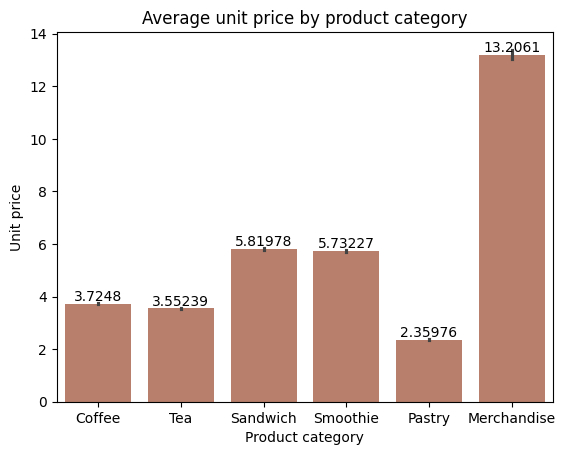

In [93]:
coffee_sales_dataset_cleaned = pd.read_csv("cleaned_dataset.csv")
ax = seaborn.barplot(data=coffee_sales_dataset_cleaned,x="product_category",y="unit_price",color="#c37960")
ax.bar_label(ax.containers[0])
plt.xlabel("Product category",color="black")
plt.ylabel("Unit price")
plt.title("Average unit price by product category",color="black");

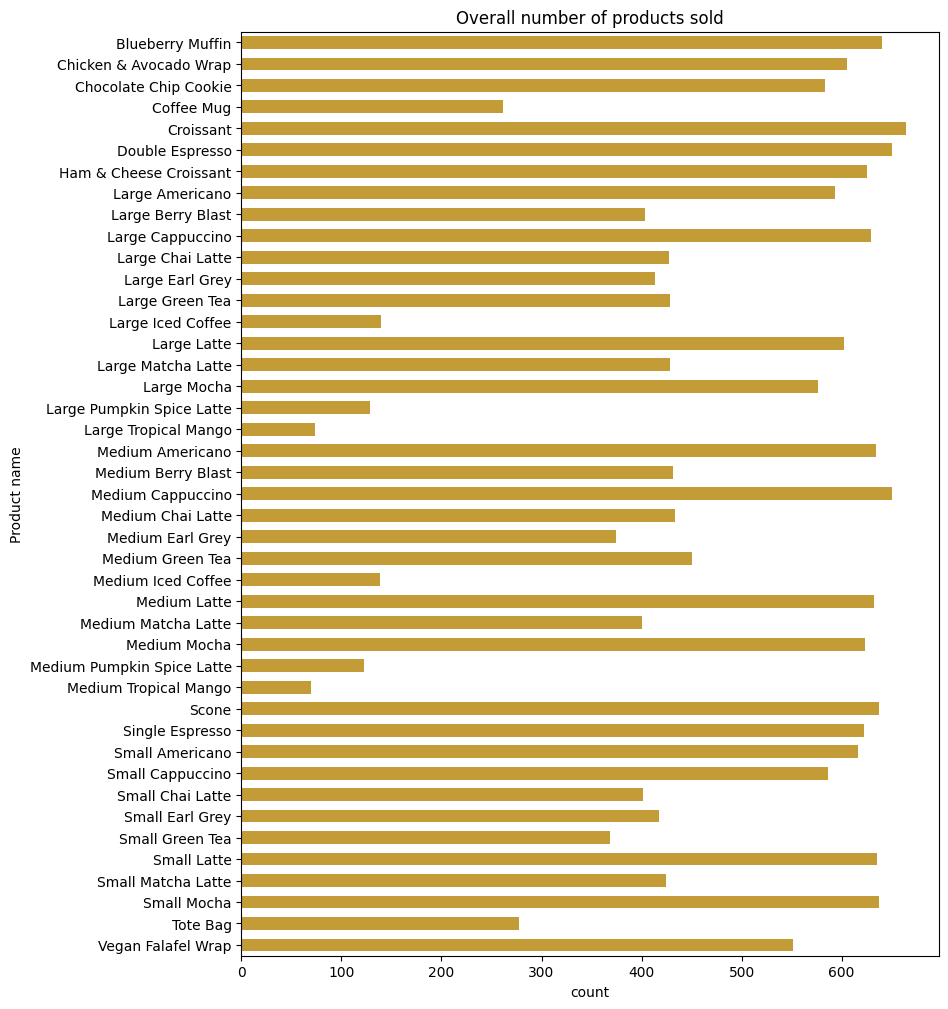

In [94]:
f,ax = plt.subplots(1,1,figsize=(9,12))
seaborn.countplot(coffee_sales_dataset_cleaned.sort_values(by="product_name"),y="product_name",color="goldenrod",width=0.6)
ax.set_ylabel("Product name")
ax.set_title("Overall number of products sold");

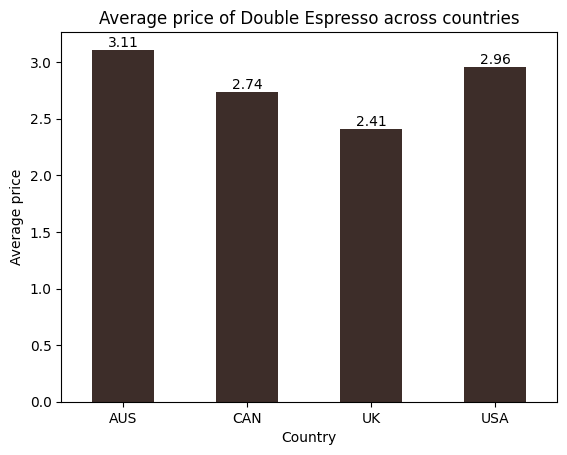

In [95]:
avg_price_double_espresso_across_countries = coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["product_name"]=="Double Espresso"].groupby("country")["unit_price"].mean().round(2)
ax=seaborn.barplot(x=avg_price_double_espresso_across_countries.index,y=avg_price_double_espresso_across_countries.values,color="#402B26",width=0.5)
ax.bar_label(ax.containers[0])
plt.xlabel("Country")
plt.ylabel("Average price")
plt.title("Average price of Double Espresso across countries");

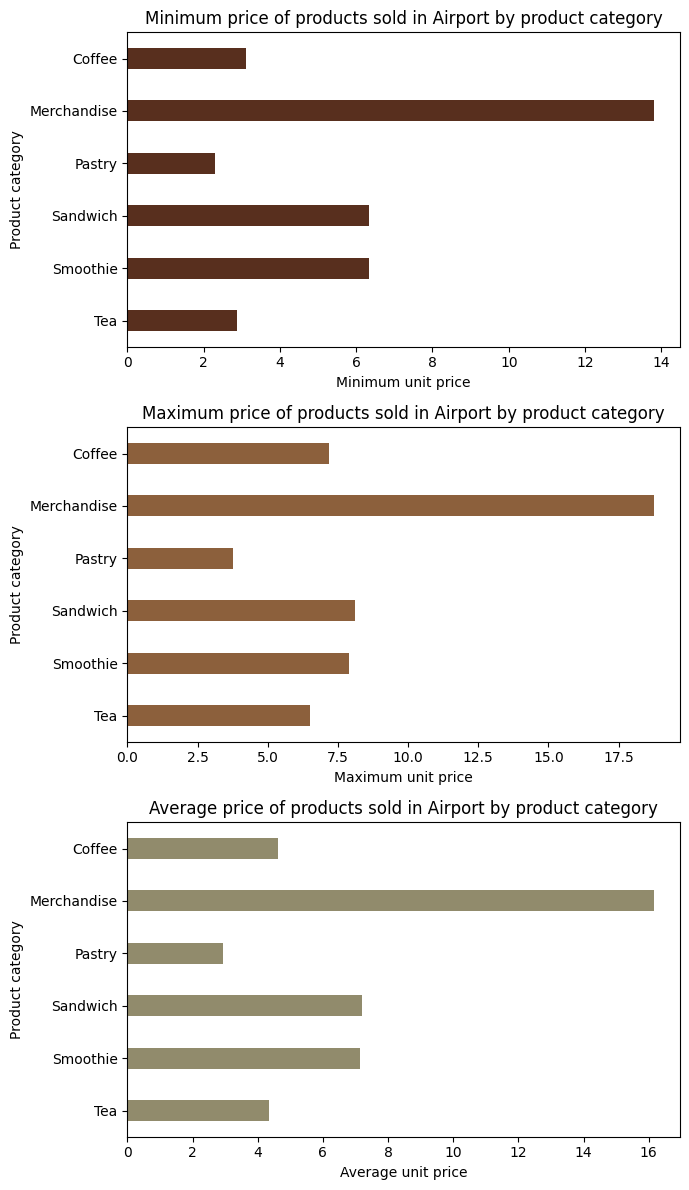

In [96]:
f,ax = plt.subplots(3,1,figsize=(7,12))
min_price_product_category = coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["store_type"]=="Airport"].groupby("product_category")["unit_price"].min()
max_price_product_category = coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["store_type"]=="Airport"].groupby("product_category")["unit_price"].max()
avg_price_product_category = coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["store_type"]=="Airport"].groupby("product_category")["unit_price"].mean()
seaborn.barplot(y=min_price_product_category.index,x=min_price_product_category.values,ax=ax[0],width=0.4,color="#622B14")
seaborn.barplot(y=max_price_product_category.index,x=max_price_product_category.values,ax=ax[1],width=0.4,color="#995F2F")
seaborn.barplot(y=avg_price_product_category.index,x=avg_price_product_category.values,ax=ax[2],width=0.4,color="#978F66")
ax[0].set_xlabel("Minimum unit price")
ax[1].set_xlabel("Maximum unit price")
ax[2].set_xlabel("Average unit price")
for _ in range(3):
    ax[_].set_ylabel("Product category")
ax[0].set_title("Minimum price of products sold in Airport by product category")
ax[1].set_title("Maximum price of products sold in Airport by product category")
ax[2].set_title("Average price of products sold in Airport by product category")
plt.tight_layout()

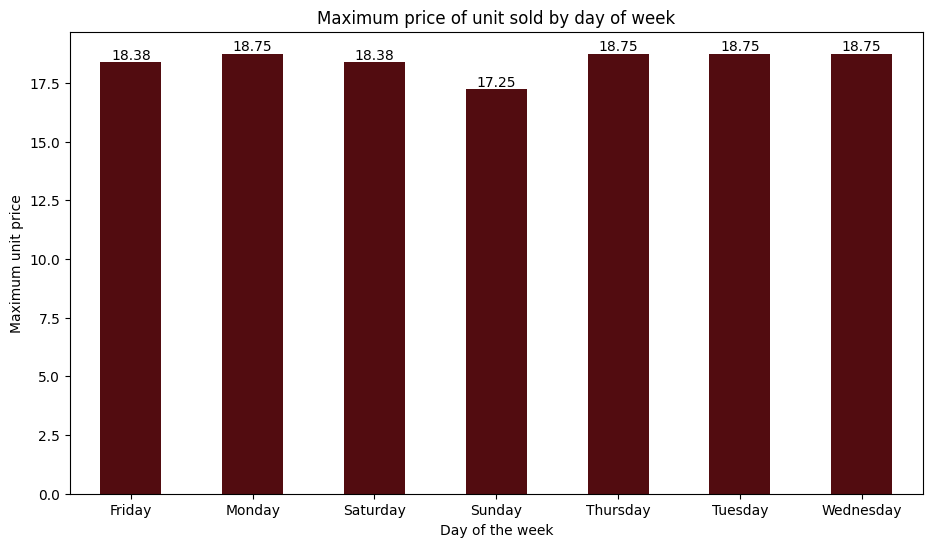

In [97]:
plt.figure(figsize=(11,6))
ax = seaborn.barplot(x=coffee_sales_dataset_cleaned.groupby("dayWeek")["unit_price"].max().index,y=coffee_sales_dataset_cleaned.groupby("dayWeek")["unit_price"].max().values,width=0.5,color="#5E0006")
ax.bar_label(ax.containers[0])
plt.xlabel("Day of the week")
plt.ylabel("Maximum unit price")
plt.title("Maximum price of unit sold by day of week");

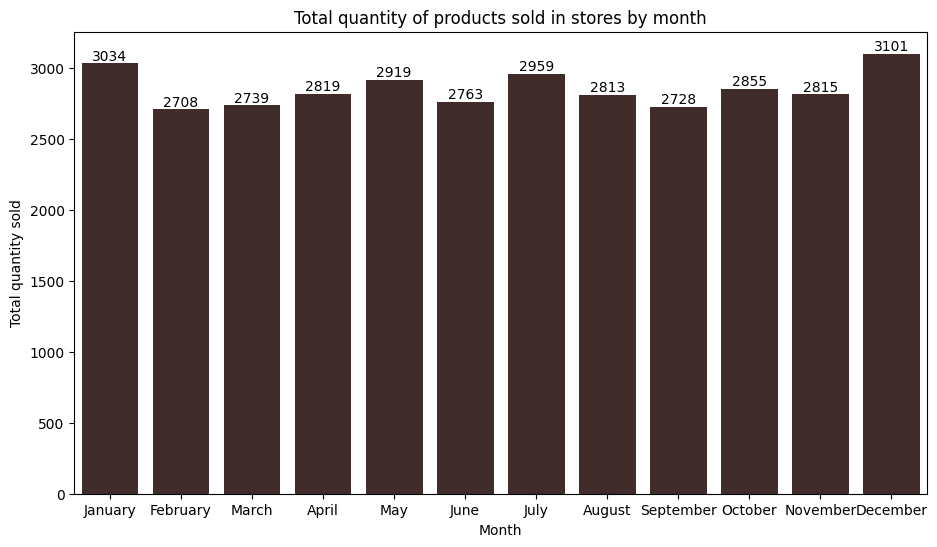

In [98]:
plt.figure(figsize=(11,6))
ax=seaborn.barplot(data=coffee_sales_dataset_cleaned,x="month_name",y="quantity",estimator="sum",errorbar=None,color="#452829")
ax.bar_label(ax.containers[0])
plt.xlabel("Month")
plt.ylabel("Total quantity sold")
plt.title("Total quantity of products sold in stores by month");

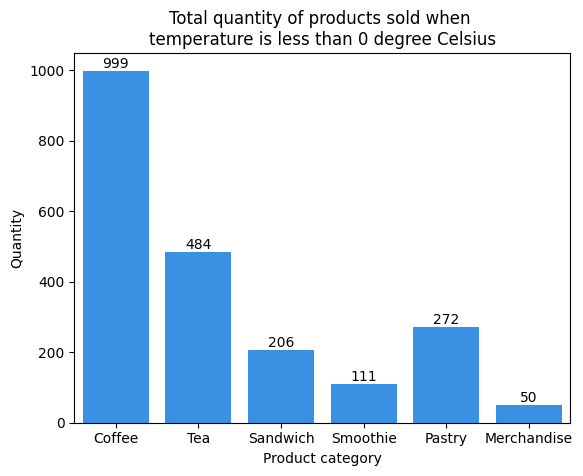

In [99]:
ax=seaborn.barplot(data=coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["temperature_c"]<0],x="product_category",y="quantity",estimator="sum",errorbar=None,color="dodgerblue")
ax.bar_label(ax.containers[0])
plt.xlabel("Product category")
plt.ylabel("Quantity")
plt.title("Total quantity of products sold when \ntemperature is less than 0 degree Celsius");

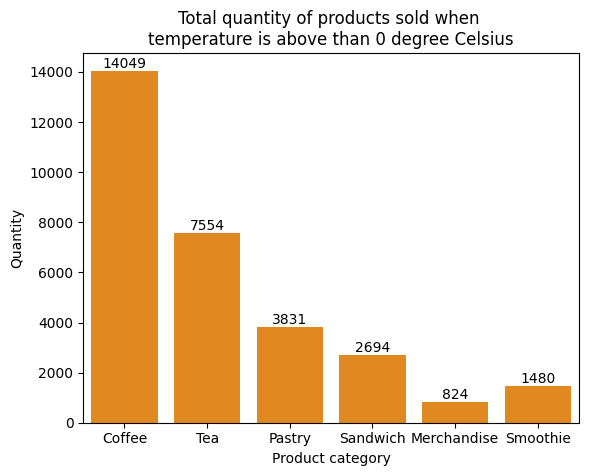

In [100]:
ax=seaborn.barplot(data=coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["temperature_c"]>0],x="product_category",y="quantity",estimator="sum",errorbar=None,color="darkorange")
ax.bar_label(ax.containers[0])
plt.xlabel("Product category")
plt.ylabel("Quantity")
plt.title("Total quantity of products sold when \ntemperature is above than 0 degree Celsius");

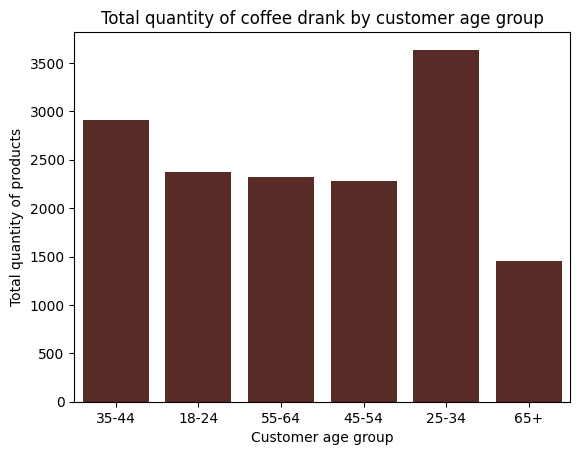

In [101]:
coffee_agegroup=coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["product_category"]=="Coffee"]
seaborn.barplot(coffee_agegroup,x="customer_age_group",y="quantity",estimator="sum",errorbar=None,color="#60241E")
plt.xlabel("Customer age group")
plt.ylabel("Total quantity of products")
plt.title("Total quantity of coffee drank by customer age group");

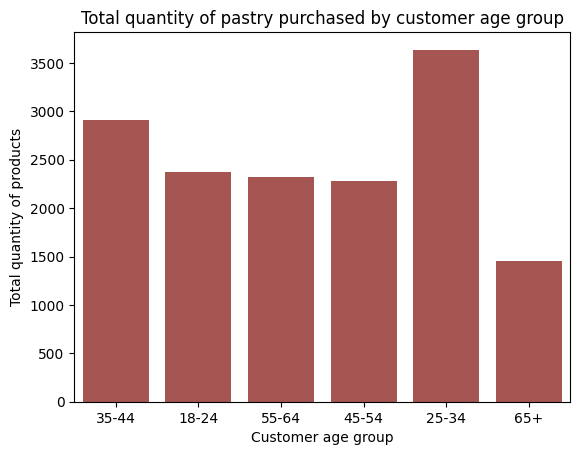

In [102]:
pastry_agegroup=coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["product_category"]=="Pastry"]
seaborn.barplot(coffee_agegroup,x="customer_age_group",y="quantity",estimator="sum",errorbar=None,color="#B34A44")
plt.xlabel("Customer age group")
plt.ylabel("Total quantity of products")
plt.title("Total quantity of pastry purchased by customer age group");

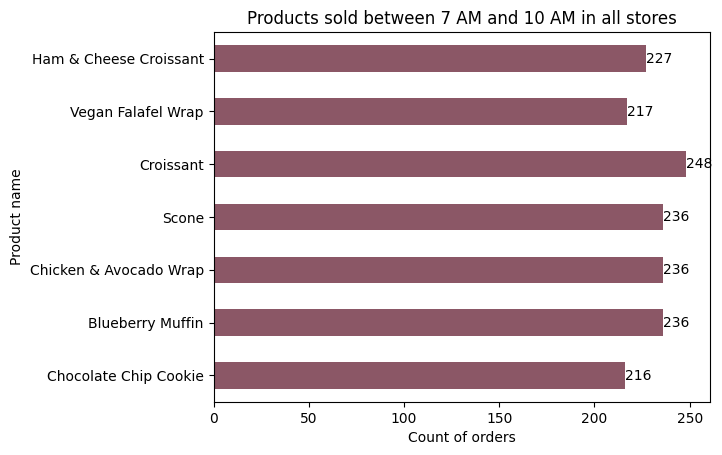

In [103]:
morning_eatables = coffee_sales_dataset_cleaned[(coffee_sales_dataset_cleaned["hour_time"]>=7)&(coffee_sales_dataset_cleaned["hour_time"]<=10)&((coffee_sales_dataset_cleaned["product_category"]=="Pastry")|(coffee_sales_dataset_cleaned["product_category"]=="Sandwich"))]
ax=seaborn.countplot(data=morning_eatables,y="product_name",color="#944E63",width=0.5)
ax.bar_label(ax.containers[0])
plt.xlabel("Count of orders")
plt.ylabel("Product name")
plt.title("Products sold between 7 AM and 10 AM in all stores");

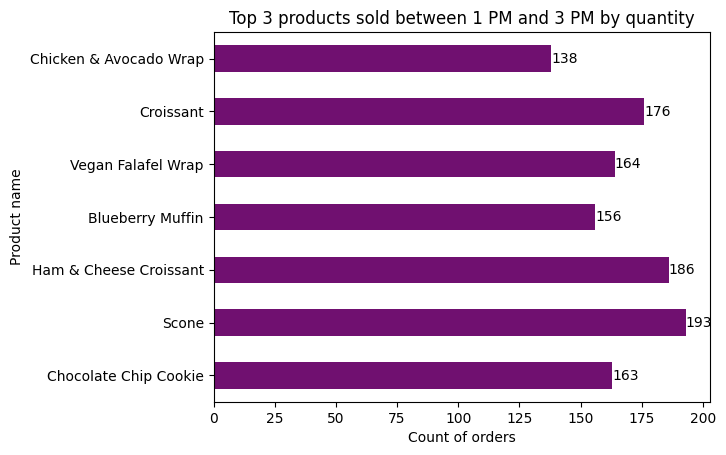

In [104]:
noon_eatables = coffee_sales_dataset_cleaned[(coffee_sales_dataset_cleaned["hour_time"]>=13)&(coffee_sales_dataset_cleaned["hour_time"]<=15)&((coffee_sales_dataset_cleaned["product_category"]=="Pastry")|(coffee_sales_dataset_cleaned["product_category"]=="Sandwich"))]
ax=seaborn.barplot(data=noon_eatables,y="product_name",x="quantity",estimator="sum",color="purple",width=0.5,errorbar=None)
ax.bar_label(ax.containers[0])
plt.xlabel("Count of orders")
plt.ylabel("Product name")
plt.title("Top 3 products sold between 1 PM and 3 PM by quantity");

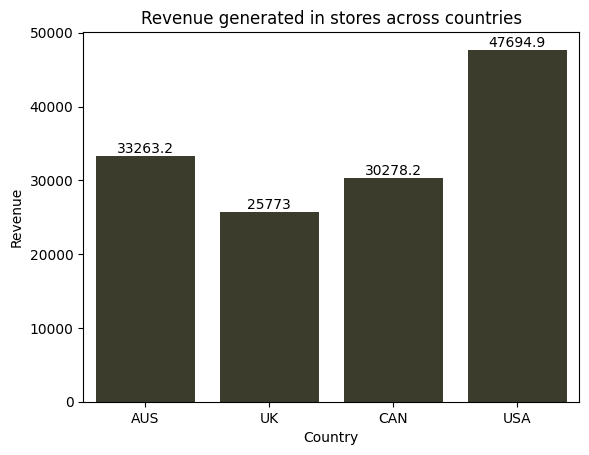

In [105]:
ax=seaborn.barplot(coffee_sales_dataset_cleaned,x="country",y="total_amount",estimator="sum",errorbar=None,color="#3E3F29")
ax.bar_label(ax.containers[0])
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Revenue generated in stores across countries");

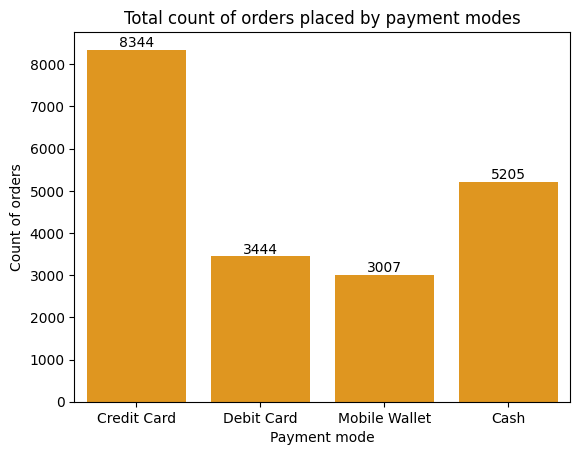

In [106]:
ax=seaborn.countplot(data=coffee_sales_dataset_cleaned,x="payment_method",color="#FF9D00")
ax.bar_label(ax.containers[0])
plt.xlabel("Payment mode")
plt.ylabel("Count of orders")
plt.title("Total count of orders placed by payment modes");

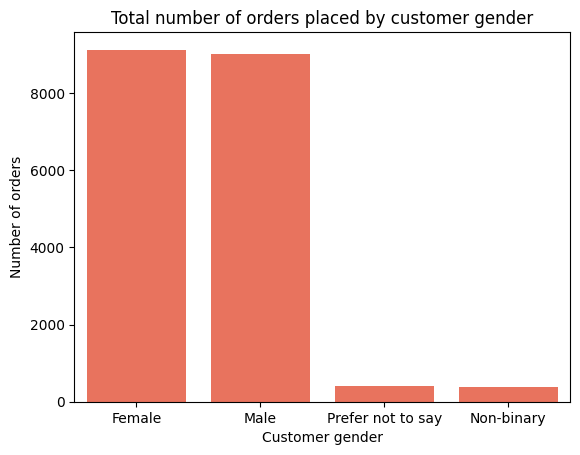

In [107]:
seaborn.countplot(coffee_sales_dataset_cleaned,x="customer_gender",color="tomato")
plt.xlabel("Customer gender")
plt.ylabel("Number of orders")
plt.title("Total number of orders placed by customer gender");

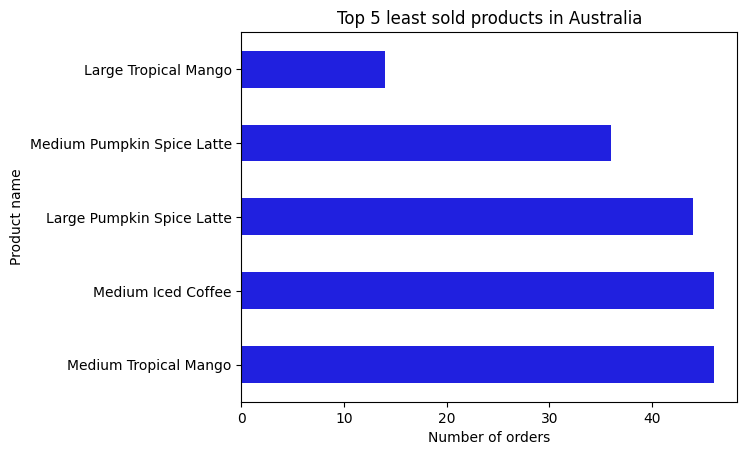

In [108]:
products_aus_quantity = coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["country"]=="AUS"].groupby("product_name")["quantity"].sum().sort_values().head()
seaborn.barplot(y=products_aus_quantity.index,x=products_aus_quantity.values,color="blue",width=0.5)
plt.ylabel("Product name")
plt.xlabel("Number of orders")
plt.title("Top 5 least sold products in Australia");

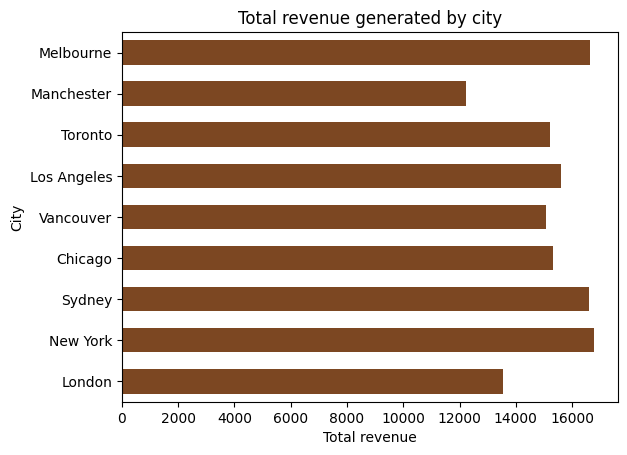

In [109]:
seaborn.barplot(coffee_sales_dataset_cleaned,y="city",x="total_amount",estimator="sum",errorbar=None,color="saddlebrown",width=0.6)
plt.xlabel("Total revenue")
plt.ylabel("City")
plt.title("Total revenue generated by city");

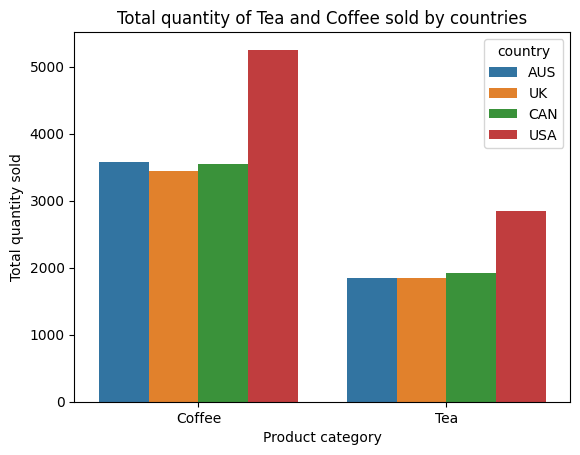

In [110]:
countrywise_tea_coffee_qty = coffee_sales_dataset_cleaned[(coffee_sales_dataset_cleaned["product_category"]=="Tea")|(coffee_sales_dataset_cleaned["product_category"]=="Coffee")]
seaborn.barplot(countrywise_tea_coffee_qty,x="product_category",y="quantity",hue="country",errorbar=None,estimator="sum")
plt.xlabel("Product category")
plt.ylabel("Total quantity sold")
plt.title("Total quantity of Tea and Coffee sold by countries");

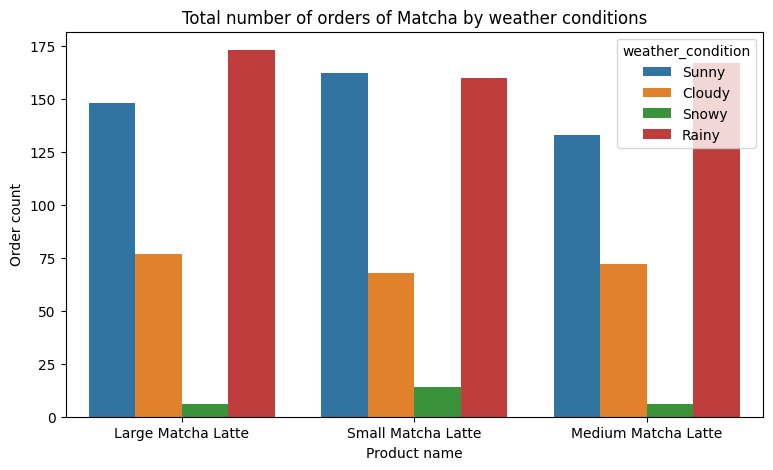

In [111]:
plt.figure(figsize=(9,5))
seaborn.countplot(coffee_sales_dataset_cleaned[coffee_sales_dataset_cleaned["product_name"].str.contains("Matcha")],x="product_name",hue="weather_condition")
plt.xlabel("Product name")
plt.ylabel("Order count")
plt.title("Total number of orders of Matcha by weather conditions");